# TRAFFIC PREDICTION MODEL COMPARISON

---

## About the Author
**Name:** Chahyaandida Ishaya  
**ID:** 253307014  
**Programme:** MSc. Artificial Intelligence with Thesis  
**Institution:** Istanbul Okan University  
**Supervisor:** Prof. HAKAN OCAL  

**Course:** AIE514 - Advanced Machine Learning  
**Project Type:** Mid-Term Project

---

## 1. Introduction

Traffic congestion and flow prediction are critical challenges in urban planning and transportation management. Accurately forecasting traffic patterns can lead to reduced travel times, lower carbon emissions, and improved road safety.

This project aims to evaluate and compare the performance of traditional **Machine Learning (ML)** models against **Deep Neural Network (DNN)** architectures using traffic datasets. We focus on two specific models from each category:

*   **Machine Learning Models:** Random Forest and XGBoost.
*   **Deep Learning Models:** Long Short-Term Memory (LSTM) networks and Convolutional Neural Networks (CNN).

By comparing these approaches, we seek to understand the trade-offs between model interpretability, computational efficiency, and predictive accuracy in the context of temporal and spatial traffic data.

## 2. About the Dataset: GTSRB

The **German Traffic Sign Recognition Benchmark (GTSRB)** is a widely used dataset for multiclass classification in computer vision.

https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign

### Key Characteristics:
*   **Classes:** 43 different traffic sign categories (e.g., speed limits, warnings, priority signs).
*   **Images:** Over 50,000 images in total.
*   **Format:** Images vary in size and are provided in PPM format (often converted to PNG/JPG for ML pipelines).
*   **Challenges:** The images feature varying lighting conditions, motion blur, occlusions, and physical damage to signs, making it a robust test for both ML and DNN models.

### * Load Important Libraries

In [26]:
# Data hub
import kagglehub

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# XGBoost
from xgboost import XGBRegressor

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Conv1D, Flatten

# Preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## 3. Dataset Loading

In [5]:
import kagglehub

# Download latest version of the GTSRB dataset
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Path to dataset files: /kaggle/input/gtsrb-german-traffic-sign


### 4. EDA
In this section, we visualize random samples from different classes to understand the image quality, lighting variations, and scaling across the GTSRB dataset.

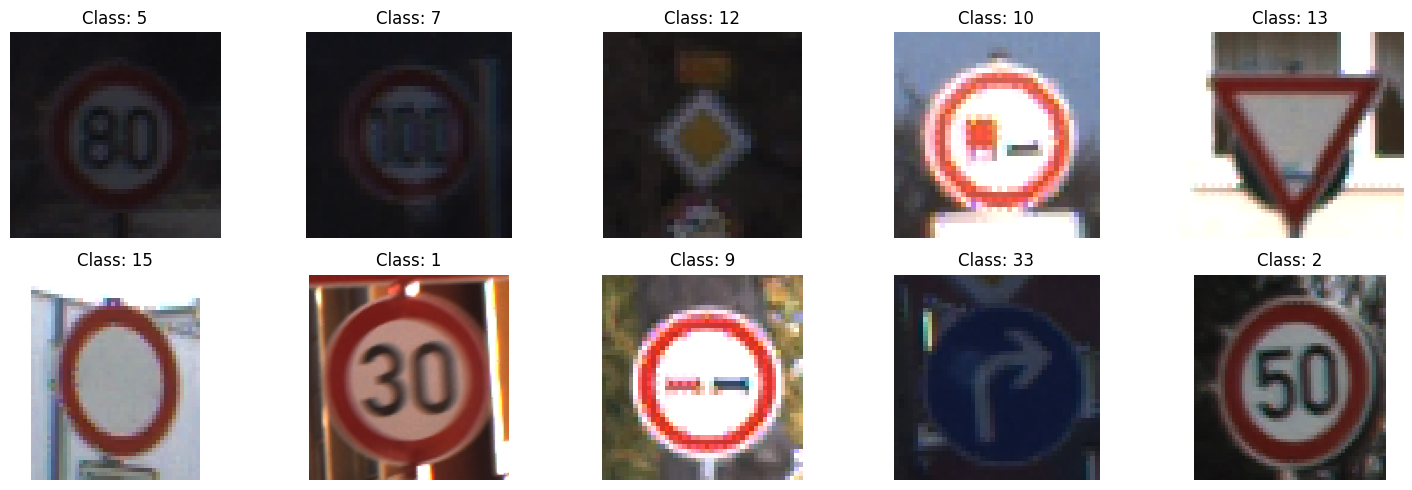

In [7]:
import matplotlib.pyplot as plt
import random
from PIL import Image

# Function to plot sample images
def plot_sample_images(df, base_path, num_samples=10):
    plt.figure(figsize=(15, 5))
    for i in range(num_samples):
        random_index = random.randint(0, len(df) - 1)
        img_path = os.path.join(base_path, df.iloc[random_index]['Path'])
        img = Image.open(img_path)

        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.title(f"Class: {df.iloc[random_index]['ClassId']}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_sample_images(df, path)

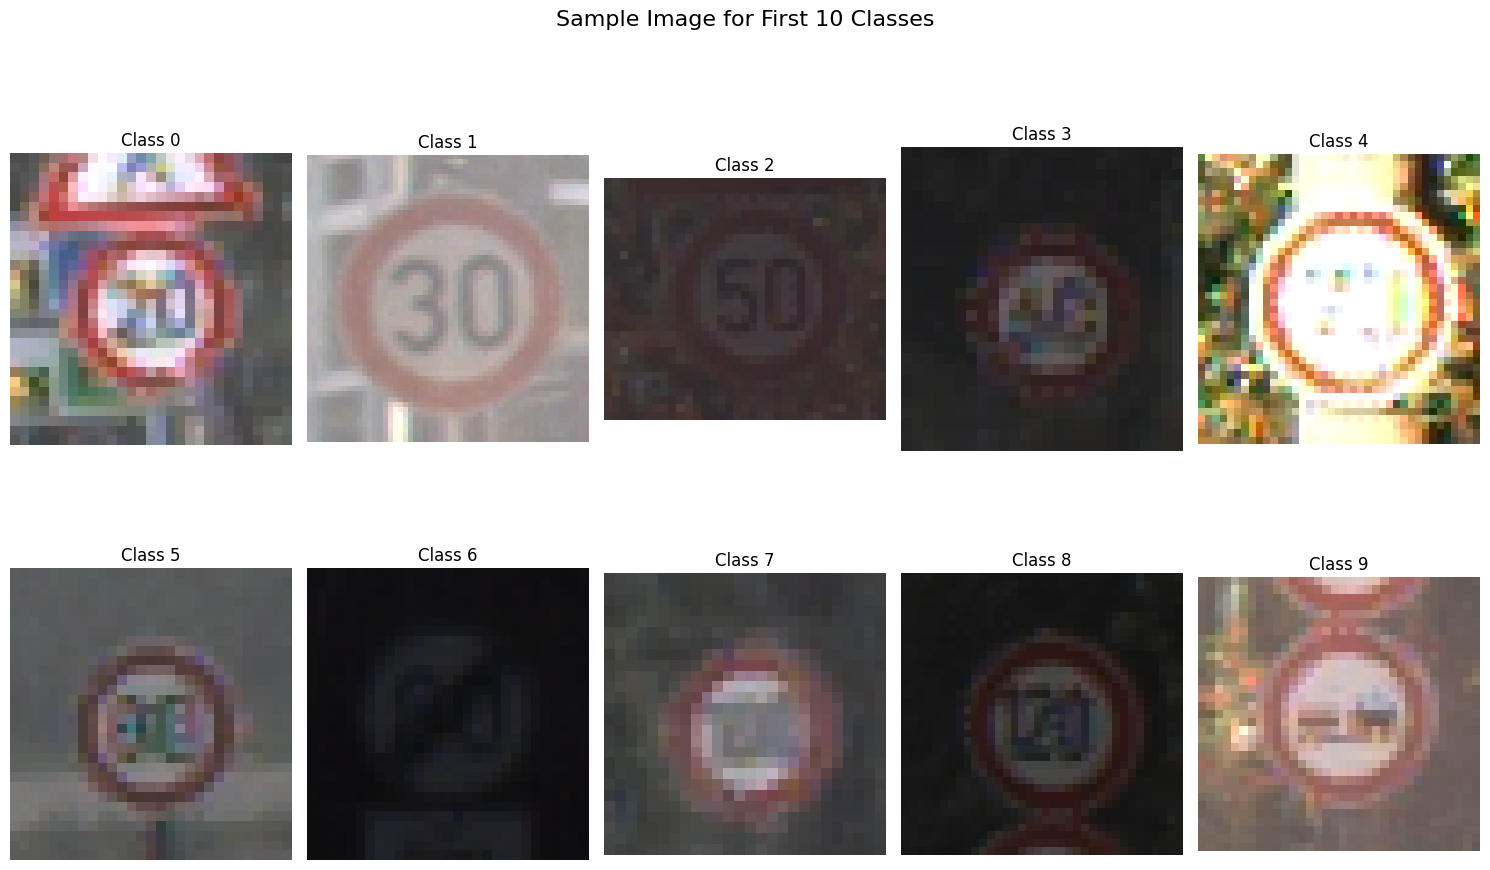

In [9]:
def plot_class_grid(df, base_path, classes_to_show=10):
    plt.figure(figsize=(15, 10))
    for i in range(classes_to_show):
        # Get the first image path for each class
        class_sample = df[df['ClassId'] == i].iloc[0]
        img_path = os.path.join(base_path, class_sample['Path'])
        img = Image.open(img_path)

        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.title(f"Class {i}")
        plt.axis('off')
    plt.suptitle('Sample Image for First 10 Classes', fontsize=16)
    plt.tight_layout()
    plt.show()

plot_class_grid(df, path)

In [6]:
import pandas as pd
import os

# Construct the path to Train.csv
train_csv_path = os.path.join(path, 'Train.csv')

if os.path.exists(train_csv_path):
    df = pd.read_csv(train_csv_path)
    display(df.head())
    print(f"Dataset Shape: {df.shape}")
    print(f"Number of classes: {df['ClassId'].nunique()}")
else:
    print(f"Train.csv not found at {train_csv_path}. Listing directory contents:")
    print(os.listdir(path))

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


Dataset Shape: (39209, 8)
Number of classes: 43


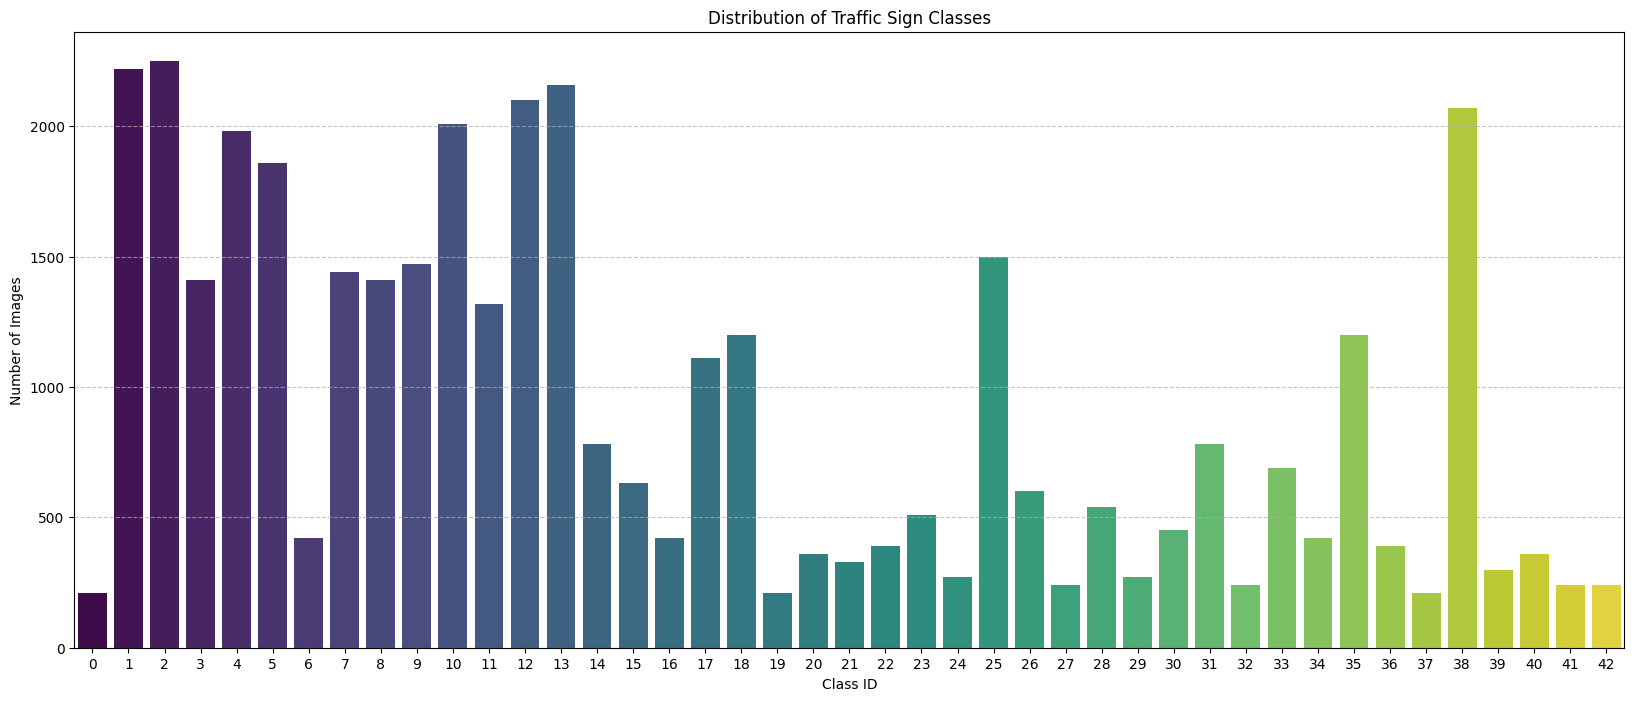

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plotting the distribution of classes
plt.figure(figsize=(20, 8))
sns.countplot(x='ClassId', data=df, hue='ClassId', palette='viridis', legend=False)
plt.title('Distribution of Traffic Sign Classes')
plt.xlabel('Class ID')
plt.ylabel('Number of Images')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 4.1. Normalization and Stardization

Before feeding images into our models, we need to standardize them. We will:
1.  **Load** the images from the paths provided in the CSV.
2.  **Resize** them to a fixed size of 32x32.
3.  **Normalize** the pixel values to be between 0 and 1.

In [10]:
import numpy as np
import cv2

def preprocess_data(df, base_path, size=(32, 32)):
    data = []
    labels = []

    for index, row in df.iterrows():
        img_path = os.path.join(base_path, row['Path'])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, size)
        data.append(image)
        labels.append(row['ClassId'])

    # Convert to numpy arrays and normalize
    X = np.array(data) / 255.0
    y = np.array(labels)
    return X, y

# Preprocess the training data
X_train, y_train = preprocess_data(df, path)
print(f"Processed Data Shape: {X_train.shape}")
print(f"Processed Labels Shape: {y_train.shape}")

Processed Data Shape: (39209, 32, 32, 3)
Processed Labels Shape: (39209,)


In [11]:
from sklearn.model_selection import train_test_split

# Split the data into training and validation sets (80% train, 20% validation)
X_train_split, X_val, y_train_split, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

print(f"Training set shape: {X_train_split.shape}")
print(f"Validation set shape: {X_val.shape}")

Training set shape: (31367, 32, 32, 3)
Validation set shape: (7842, 32, 32, 3)


## 5. Baseline Machine Learning Models

In this section, we implement **Random Forest** and **XGBoost**. Since these models do not inherently handle spatial dependencies like CNNs, we must flatten the 3D image arrays into 1D vectors.

In [12]:
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score

# Flatten the image data for ML models
X_train_flat = X_train_split.reshape(X_train_split.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)

print(f"Flattened Training Shape: {X_train_flat.shape}")
print(f"Flattened Validation Shape: {X_val_flat.shape}")

Flattened Training Shape: (31367, 3072)
Flattened Validation Shape: (7842, 3072)


In [13]:
# Initialize and train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_model.fit(X_train_flat, y_train_split)

# Predict and evaluate Random Forest
y_pred_rf = rf_model.predict(X_val_flat)
rf_acc = accuracy_score(y_val, y_pred_rf)

print("--- Random Forest Evaluation ---")
print(f"Accuracy: {rf_acc:.4f}")
print(classification_report(y_val, y_pred_rf))

--- Random Forest Evaluation ---
Accuracy: 0.9816
              precision    recall  f1-score   support

           0       1.00      0.86      0.92        42
           1       0.95      0.99      0.97       444
           2       0.95      0.96      0.95       450
           3       0.97      0.95      0.96       282
           4       0.98      0.98      0.98       396
           5       0.95      0.95      0.95       372
           6       0.99      1.00      0.99        84
           7       0.97      0.96      0.97       288
           8       0.95      0.98      0.96       282
           9       0.99      0.99      0.99       294
          10       0.99      1.00      1.00       402
          11       0.99      0.98      0.99       264
          12       1.00      1.00      1.00       420
          13       0.99      1.00      0.99       432
          14       0.99      0.99      0.99       156
          15       1.00      0.98      0.99       126
          16       1.00      1.

In [14]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

# Initialize and train Linear SVM
# LinearSVC is generally faster than SVC with an RBF kernel for large datasets
svm_model = LinearSVC(random_state=42, max_iter=1000, dual='auto')
svm_model.fit(X_train_flat, y_train_split)

# Predict and evaluate SVM
y_pred_svm = svm_model.predict(X_val_flat)
svm_acc = accuracy_score(y_val, y_pred_svm)

print("--- SVM Evaluation ---")
print(f"Accuracy: {svm_acc:.4f}")
print(classification_report(y_val, y_pred_svm))

--- SVM Evaluation ---
Accuracy: 0.9364
              precision    recall  f1-score   support

           0       0.80      0.79      0.80        42
           1       0.91      0.90      0.90       444
           2       0.87      0.91      0.89       450
           3       0.92      0.85      0.88       282
           4       0.91      0.91      0.91       396
           5       0.84      0.87      0.85       372
           6       0.96      0.96      0.96        84
           7       0.88      0.92      0.90       288
           8       0.88      0.95      0.91       282
           9       0.98      0.95      0.96       294
          10       0.96      0.98      0.97       402
          11       0.98      0.91      0.94       264
          12       0.99      0.98      0.99       420
          13       0.99      0.98      0.98       432
          14       1.00      0.95      0.97       156
          15       0.95      0.94      0.94       126
          16       0.99      1.00      0.

### 6. Comprehensive Model Evaluation

Beyond accuracy, we use the **Confusion Matrix** to identify which classes are being misclassified.

Random Forest Confusion Matrix:


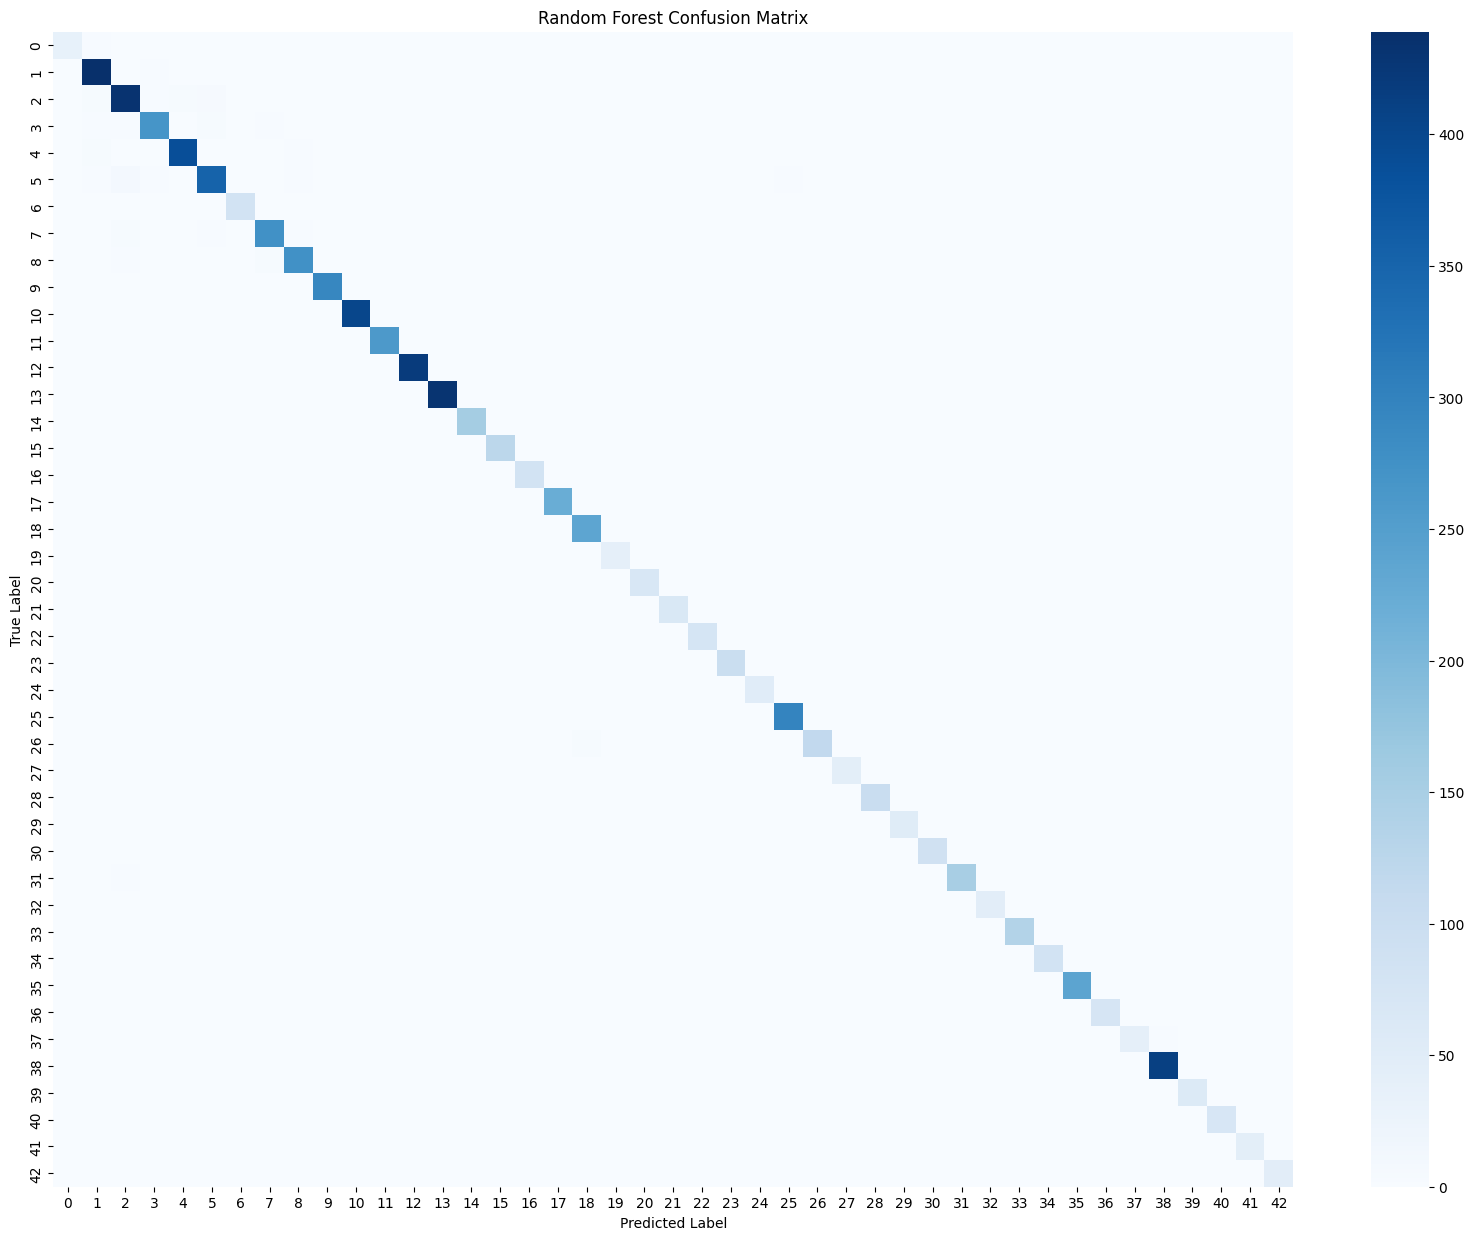

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(20, 15))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Visualize Confusion Matrix for our best baseline (Random Forest)
print("Random Forest Confusion Matrix:")
plot_confusion_matrix(y_val, y_pred_rf, title='Random Forest Confusion Matrix')

In [16]:
import pandas as pd

# Create a comparison table for the baseline models
comparison_data = {
    'Model': ['Random Forest', 'Linear SVM'],
    'Accuracy': [rf_acc, svm_acc]
}

comparison_df = pd.DataFrame(comparison_data)

# Formatting for display
comparison_df['Accuracy'] = comparison_df['Accuracy'].map('{:.2%}'.format)

print("### Baseline Model Comparison")
display(comparison_df)

### Baseline Model Comparison


,Model,Accuracy
0,Random Forest,98.16%
1,Linear SVM,93.64%


## 7. Deep Learning Models: CNN

Convolutional Neural Networks (CNNs) are the industry standard for image classification. Unlike the flattened input used for ML models, the CNN will take the full 32x32x3 image tensor as input.

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_cnn_model(input_shape=(32, 32, 3), num_classes=43):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

cnn_model = build_cnn_model()
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         2,795 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,715 (487.17 KB)

 Trainable params: 124,715 (487.17 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9968 - loss: 0.0119 - val_accuracy: 0.9852 - val_loss: 0.0793
Epoch 2/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9957 - loss: 0.0152 - val_accuracy: 0.9894 - val_loss: 0.0634
Epoch 3/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9980 - loss: 0.0064 - val_accuracy: 0.9862 - val_loss: 0.0703
Epoch 4/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9964 - loss: 0.0120 - val_accuracy: 0.9901 - val_loss: 0.0600
Epoch 5/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9973 - loss: 0.0094 - val_accuracy: 0.9901 - val_loss: 0.0582
Epoch 6/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9965 - loss: 0.0118 - val_accuracy: 0.9897 - val_loss: 0.0605
Epoch 7/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9995 - loss: 0.0020 - val_accuracy: 0.9926 - val_loss: 0.0545
Epoch 8/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9964 - loss: 0.0120 - val_accuracy: 0.

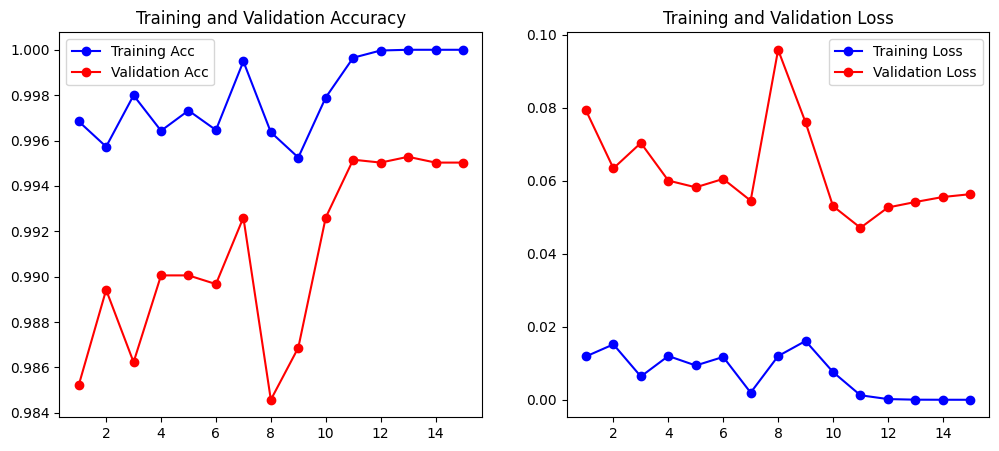

In [19]:
def plot_training_curves(history):
    """Helper function to plot Accuracy and Loss curves for Deep Learning models"""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Acc')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Acc')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.show()

history_cnn = cnn_model.fit(X_train_split, y_train_split,
                            epochs=15,
                            validation_data=(X_val, y_val),
                            batch_size=64)

# Now the function is defined and can be called successfully
plot_training_curves(history_cnn)

## 8. Deep Learning Models: LSTM

LSTMs are recurrent neural networks often used for temporal data. In this context, we treat the image as a sequence of rows to evaluate how a sequence-based model performs on spatial data.

In [20]:
from tensorflow.keras.layers import LSTM, Dense, Input

def build_lstm_model(input_shape=(32, 32, 3), num_classes=43):
    # Flattening the last two dimensions for LSTM input (32 steps, 96 features per step)
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Reshape((32, 32 * 3)),
        layers.LSTM(128, return_sequences=False),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

lstm_model = build_lstm_model()
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 32, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       115,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137,259 (536.17 KB)

 Trainable params: 137,259 (536.17 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.2266 - loss: 2.6583 - val_accuracy: 0.4067 - val_loss: 1.8116
Epoch 2/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5439 - loss: 1.3898 - val_accuracy: 0.6115 - val_loss: 1.1655
Epoch 3/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7446 - loss: 0.7697 - val_accuracy: 0.7558 - val_loss: 0.7252
Epoch 4/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8534 - loss: 0.4481 - val_accuracy: 0.8692 - val_loss: 0.3983
Epoch 5/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9031 - loss: 0.3094 - val_accuracy: 0.9189 - val_loss: 0.2668
Epoch 6/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9329 - loss: 0.2170 - val_accuracy: 0.9327 - val_loss: 0.2130
Epoch 7/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9476 - loss: 0.1691 - val_accuracy: 0.9348 - val_loss: 0.2133
Epoch 8/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9559 - loss: 0.1426 - val_accuracy: 0.

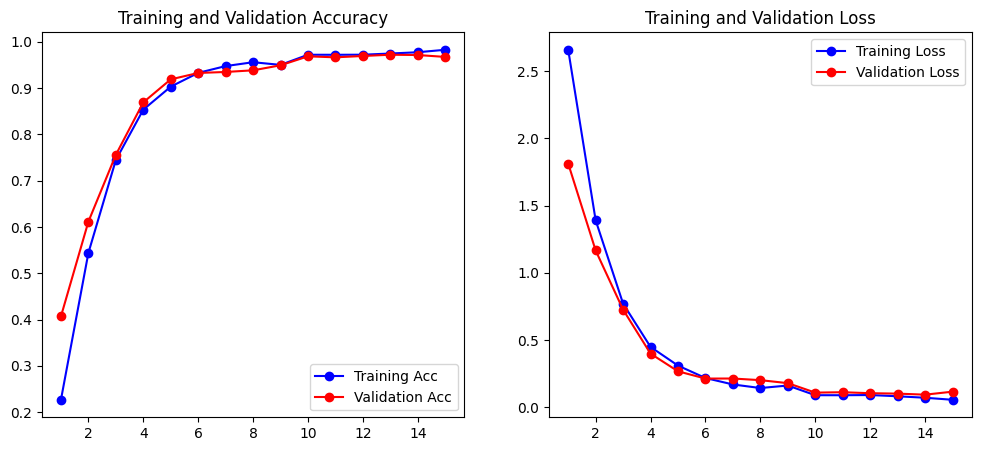

In [21]:
history_lstm = lstm_model.fit(X_train_split, y_train_split,
                             epochs=15,
                             validation_data=(X_val, y_val),
                             batch_size=64)

# Plot curves for LSTM
plot_training_curves(history_lstm)

### 9. Comprehensive Model Evaluation

Beyond accuracy, we use the **Confusion Matrix** to identify which classes are being misclassified. We also define a helper function to plot training/validation metrics for the neural networks coming up next.

In [22]:
def plot_training_curves(history):
    """Helper function to plot Accuracy and Loss curves for Deep Learning models"""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Acc')
    plt.plot(epochs, val_acc, 'ro-', label='Validation Acc')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    plt.show()

246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
--- CNN Detailed Evaluation ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        42
           1       0.99      0.99      0.99       444
           2       1.00      0.99      1.00       450
           3       0.99      0.99      0.99       282
           4       1.00      1.00      1.00       396
           5       0.99      0.99      0.99       372
           6       1.00      1.00      1.00        84
           7       1.00      0.99      1.00       288
           8       1.00      1.00      1.00       282
           9       1.00      1.00      1.00       294
          10       1.00      1.00      1.00       402
          11       1.00      0.99      0.99       264
          12       1.00      1.00      1.00       420
          13       1.00      1.00      1.00       432
          14       1.00      0.99      1.00       156
          15       0.99      1.00      1.00       126
        

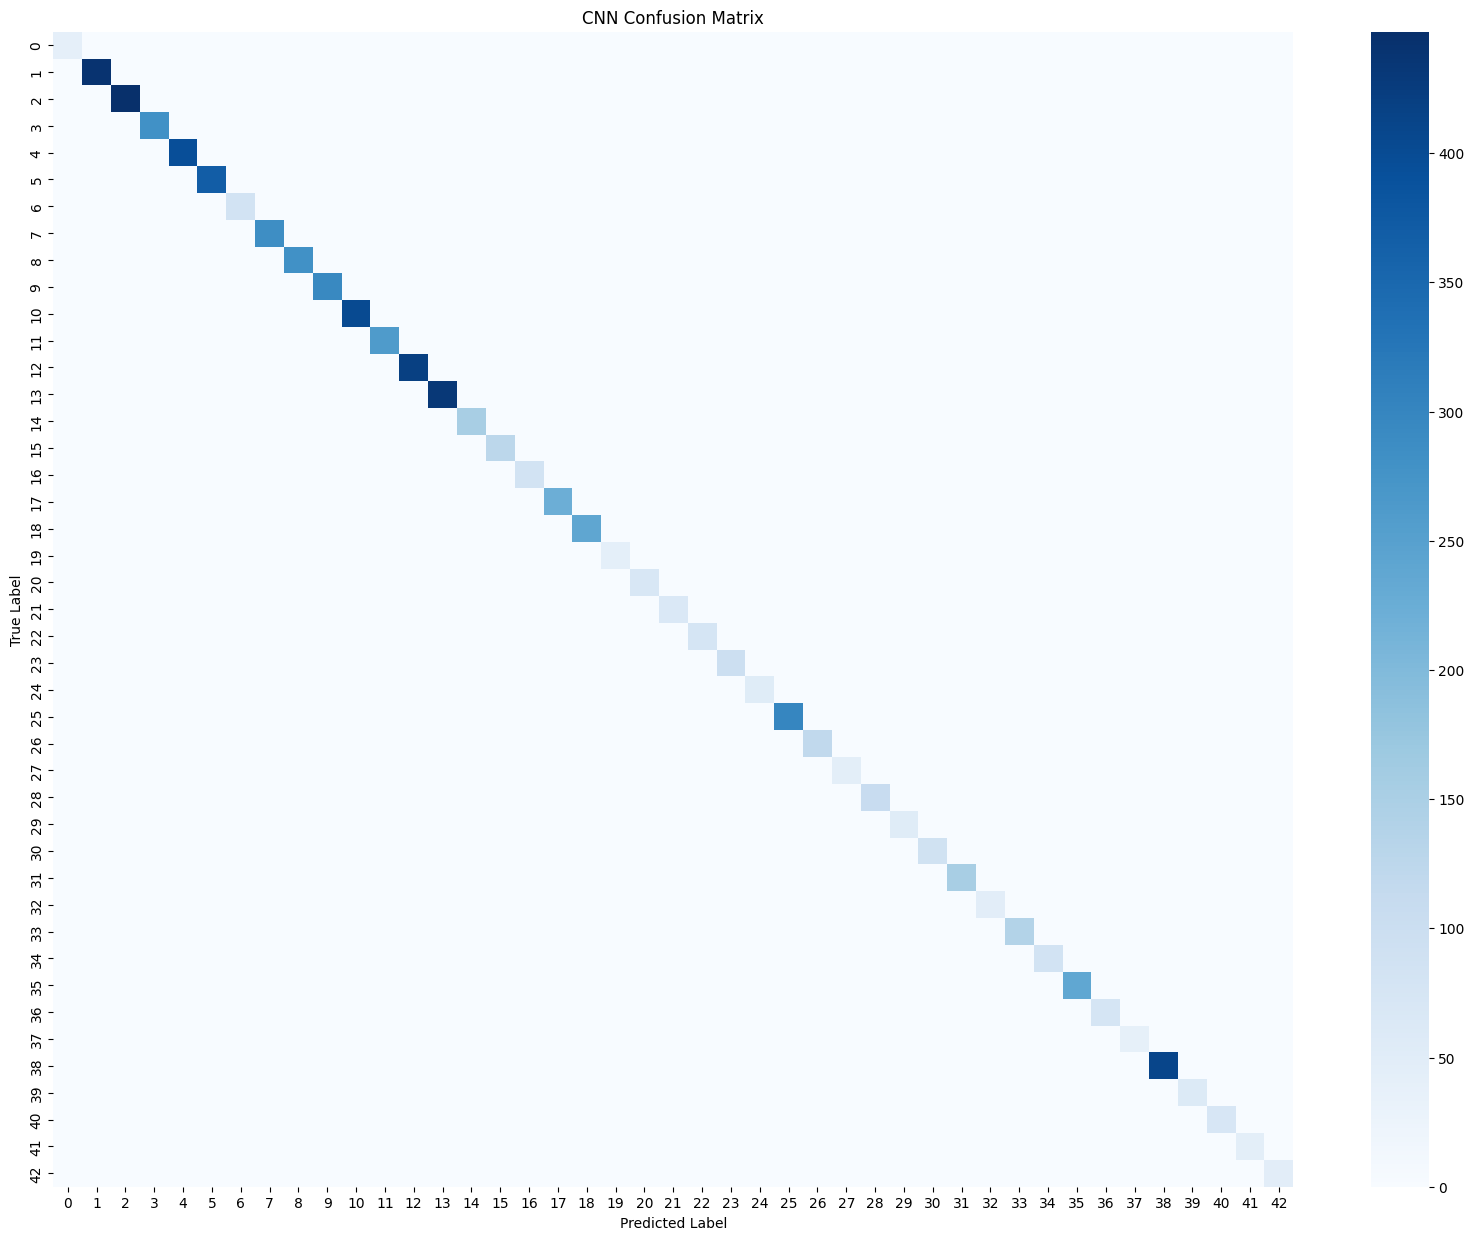

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# CNN Predictions
y_pred_cnn_probs = cnn_model.predict(X_val)
y_pred_cnn = np.argmax(y_pred_cnn_probs, axis=1)

print("--- CNN Detailed Evaluation ---")
print(classification_report(y_val, y_pred_cnn))

# Plot CNN Confusion Matrix
plot_confusion_matrix(y_val, y_pred_cnn, title='CNN Confusion Matrix')

246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
--- LSTM Detailed Evaluation ---
              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.94      0.95       444
           2       0.97      0.98      0.97       450
           3       0.98      0.93      0.95       282
           4       1.00      0.87      0.93       396
           5       0.92      0.97      0.95       372
           6       0.93      1.00      0.97        84
           7       0.92      0.97      0.95       288
           8       0.85      0.99      0.91       282
           9       0.99      0.98      0.98       294
          10       0.99      0.99      0.99       402
          11       0.98      0.93      0.95       264
          12       1.00      0.99      0.99       420
          13       1.00      0.99      0.99       432
          14       1.00      0.99      1.00       156
          15       1.00      0.98      0.99       126
       

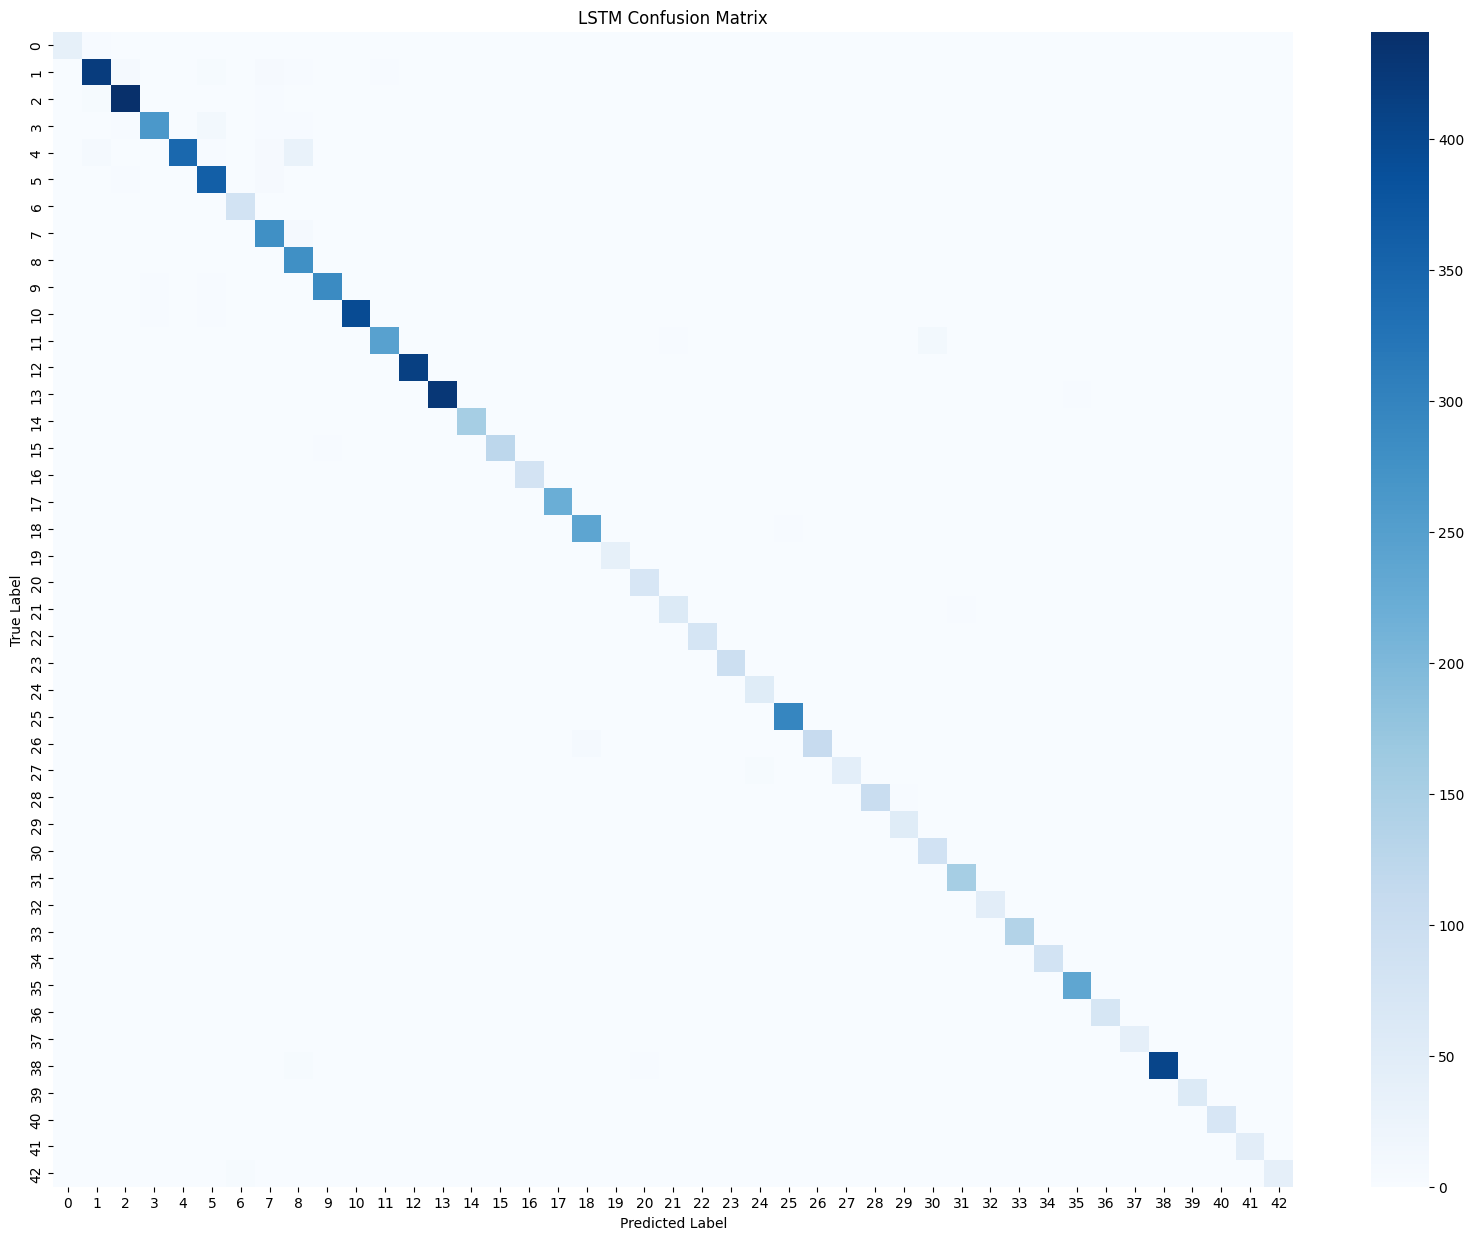

In [24]:
# LSTM Predictions
y_pred_lstm_probs = lstm_model.predict(X_val)
y_pred_lstm = np.argmax(y_pred_lstm_probs, axis=1)

print("--- LSTM Detailed Evaluation ---")
print(classification_report(y_val, y_pred_lstm))

# Plot LSTM Confusion Matrix
plot_confusion_matrix(y_val, y_pred_lstm, title='LSTM Confusion Matrix')

In [25]:
import pandas as pd

# Extract final validation accuracies from the history objects
cnn_final_acc = history_cnn.history['val_accuracy'][-1]
lstm_final_acc = history_lstm.history['val_accuracy'][-1]

# Create a consolidated comparison table
final_comparison_data = {
    'Model Type': ['Machine Learning', 'Machine Learning', 'Deep Learning', 'Deep Learning'],
    'Model Name': ['Random Forest', 'Linear SVM', 'CNN (Convolutional)', 'LSTM (Recurrent)'],
    'Validation Accuracy': [rf_acc, svm_acc, cnn_final_acc, lstm_final_acc]
}

final_comparison_df = pd.DataFrame(final_comparison_data)

# Formatting for better readability
final_comparison_df['Validation Accuracy'] = final_comparison_df['Validation Accuracy'].map('{:.2%}'.format)
final_comparison_df = final_comparison_df.sort_values(by='Validation Accuracy', ascending=False)

print("### Final Model Performance Summary")
display(final_comparison_df)

### Final Model Performance Summary


,Model Type,Model Name,Validation Accuracy
2,Deep Learning,CNN (Convolutional),99.50%
0,Machine Learning,Random Forest,98.16%
3,Deep Learning,LSTM (Recurrent),96.74%
1,Machine Learning,Linear SVM,93.64%
